# ML Pipeline - Phase 2: Huấn luyện & So Sánh Từng Bảng Quy Mô Dữ Liệu (MIMIC-III Multi-Scale Benchmark)

Notebook này huấn luyện và hiển thị kết quả **TÁCH RIÊNG TỪNG BẢNG BẢNG THEO TỪNG QUY MÔ DỮ LIỆU** giúp dễ theo dõi và đối chiếu:
- 📊 **Bảng 1**: Quy mô **1,360 Mẫu** (Bước trượt 30s - Không chồng lấp)
- 📊 **Bảng 2**: Quy mô **4,083 Mẫu** (Bước trượt 10s - Trượt 66%)
- 📊 **Bảng 3**: Quy mô **8,165 Mẫu** (Bước trượt 5s - Trượt 83%)
- 📊 **Bảng 4**: Quy mô **16,358 Mẫu** (Bước trượt 2.5s - Trượt 91%)
- 🏆 **Bảng 5**: Bảng So Sánh Đối Chiếu Mô Hình Tối Ưu Nhất Qua Các Quy Mô.

In [16]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings, joblib
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
print('✅ Nạp thành công thư viện So sánh Đa Quy Mô!')

✅ Nạp thành công thư viện So sánh Đa Quy Mô!


### 1. Huấn luyện & Xuất Bảng Đánh Giá Tách Biệt Cho Từng Quy Mô Dữ Liệu

In [17]:
processed_dir_candidates = ['../../../data/processed', '../../data/processed', 'data/processed']
processed_dir = next((d for d in processed_dir_candidates if os.path.exists(d)), '../../data/processed')

scales_info = [
    ('1360', '1,360 Mẫu (Bước 30s - Không chồng lấp)'),
    ('4083', '4,083 Mẫu (Bước 10s - Trượt 66% - Mặc định)'),
    ('8165', '8,165 Mẫu (Bước 5s - Trượt 83%)'),
    ('16358', '16,358 Mẫu (Bước 2.5s - Trượt 91%)')
]

scale_tables = {}
summary_top_models = []

for tag, title_desc in scales_info:
    f_mm = os.path.join(processed_dir, f'mimic_minmax_{tag}.csv')
    f_zs = os.path.join(processed_dir, f'mimic_zscore_{tag}.csv')
    
    if not os.path.exists(f_mm):
        continue
        
    df_mm = pd.read_csv(f_mm)
    df_zs = pd.read_csv(f_zs)
    
    X_mm = df_mm.drop(columns=['status'])
    y = df_mm['status']
    X_zs = df_zs.drop(columns=['status'])
    
    Xmm_train, Xmm_test, y_train, y_test = train_test_split(X_mm, y, test_size=0.2, random_state=42, stratify=y)
    Xzs_train, Xzs_test, _, _ = train_test_split(X_zs, y, test_size=0.2, random_state=42, stratify=y)
    
    # Huấn luyện mô hình
    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(Xzs_train, y_train)
    xgb_m = xgb.XGBClassifier(max_depth=4, learning_rate=0.05, n_estimators=150, random_state=42, eval_metric='logloss').fit(Xmm_train, y_train)
    mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=200, random_state=42).fit(Xmm_train, y_train)
    svm = SVC(probability=True, random_state=42).fit(Xzs_train, y_train)
    rf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=42).fit(Xmm_train, y_train)
    
    voting = VotingClassifier([
        ('svm', svm), ('xgb', xgb_m), ('rf', rf), ('mlp', mlp)
    ], voting='soft', weights=[1.5, 2.0, 1.0, 1.0]).fit(Xmm_train, y_train)
    
    stacking = StackingClassifier([
        ('xgb', xgb_m), ('mlp', mlp), ('svm', svm), ('rf', rf)
    ], final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1).fit(Xmm_train, y_train)
    
    models_dict = {
        'Stacking Ensemble (Meta-Learner)': (stacking, Xmm_test),
        'Soft Voting Ensemble': (voting, Xmm_test),
        'XGBoost (Tuned)': (xgb_m, Xmm_test),
        'Neural Network / MLP': (mlp, Xmm_test),
        'Logistic Regression': (lr, Xzs_test)
    }
    
    eval_rows = []
    for name, (model, X_te) in models_dict.items():
        preds = model.predict(X_te)
        prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else preds
        cm = confusion_matrix(y_test, preds)
        tn, fp, fn, tp = cm.ravel()
        
        eval_rows.append({
            'Model': name,
            'Recall (Sensitivity)': recall_score(y_test, preds),
            'F1-Score': f1_score(y_test, preds),
            'ROC-AUC': roc_auc_score(y_test, prob),
            'Accuracy': accuracy_score(y_test, preds),
            'Precision': precision_score(y_test, preds),
            'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
            'False Negative (FN)': fn
        })
        
    df_scale = pd.DataFrame(eval_rows).sort_values(by=['Accuracy', 'Recall (Sensitivity)'], ascending=False).reset_index(drop=True)
    badges = ['🥇 ', '🥈 ', '🥉 '] + [''] * (len(df_scale) - 3)
    df_scale['Rank'] = [f'{badges[i]}#{i+1}' for i in range(len(df_scale))]
    df_scale = df_scale[['Rank', 'Model', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'Accuracy', 'Precision', 'Specificity', 'False Negative (FN)']]
    
    scale_tables[tag] = (title_desc, df_scale)
    
    # Lưu dòng top 1 cho bảng tổng hợp
    top_row = df_scale.iloc[0].to_dict()
    top_row['Quy Mô Data'] = f'{tag} Mẫu'
    summary_top_models.append(top_row)
    
    # # Xuất model tốt nhất cho quy mô hiện tại
    # best_model_name = df_scale['Model'].iloc[0]
    # best_model = models_dict[best_model_name][0]
    # models_dir = next((d for d in ['../../../models', '../../models', 'models'] if os.path.exists(d)), '../../models')
    # os.makedirs(models_dir, exist_ok=True)
    # model_path = os.path.join(models_dir, f'best_model_{tag}.pkl')
    # joblib.dump(best_model, model_path)
    # print(f'✅ Đã lưu model tốt nhất ({best_model_name}) cho quy mô {tag} tại: {model_path}\n')

# Hiển thị từng bảng riêng biệt
for tag, (title_desc, df_s) in scale_tables.items():
    styled_s = df_s.style.format({
        'Recall (Sensitivity)': '{:.2%}', 'F1-Score': '{:.2%}', 'ROC-AUC': '{:.4f}',
        'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Specificity': '{:.2%}', 'False Negative (FN)': '{:d}'
    }).background_gradient(cmap='Blues', subset=['Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'Accuracy'])
    
    display(HTML(f"<h3 style='color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 5px; margin-top: 25px;'>📊 BẢNG ĐÁNH GIÁ: QUY MÔ {title_desc.upper()}</h3>"))
    display(styled_s)

,Rank,Model,Recall (Sensitivity),F1-Score,ROC-AUC,Accuracy,Precision,Specificity,False Negative (FN)
0,🥇 #1,Stacking Ensemble (Meta-Learner),98.66%,98.00%,0.9940,97.79%,97.35%,96.75%,2
1,🥈 #2,Soft Voting Ensemble,98.66%,98.00%,0.9932,97.79%,97.35%,96.75%,2
2,🥉 #3,XGBoost (Tuned),98.66%,98.00%,0.9928,97.79%,97.35%,96.75%,2
3,#4,Neural Network / MLP,98.66%,98.00%,0.9909,97.79%,97.35%,96.75%,2
4,#5,Logistic Regression,98.66%,96.39%,0.9865,95.96%,94.23%,92.68%,2


,Rank,Model,Recall (Sensitivity),F1-Score,ROC-AUC,Accuracy,Precision,Specificity,False Negative (FN)
0,🥇 #1,Stacking Ensemble (Meta-Learner),99.11%,98.78%,0.9992,98.65%,98.45%,98.10%,4
1,🥈 #2,XGBoost (Tuned),99.11%,98.78%,0.9991,98.65%,98.45%,98.10%,4
2,🥉 #3,Soft Voting Ensemble,99.55%,98.67%,0.9989,98.53%,97.81%,97.29%,2
3,#4,Neural Network / MLP,98.88%,98.23%,0.9983,98.04%,97.58%,97.02%,5
4,#5,Logistic Regression,97.10%,94.77%,0.9827,94.12%,92.55%,90.51%,13


,Rank,Model,Recall (Sensitivity),F1-Score,ROC-AUC,Accuracy,Precision,Specificity,False Negative (FN)
0,🥇 #1,Neural Network / MLP,99.78%,98.84%,0.9979,98.71%,97.92%,97.43%,2
1,🥈 #2,Stacking Ensemble (Meta-Learner),99.33%,98.56%,0.9984,98.41%,97.80%,97.29%,6
2,🥉 #3,XGBoost (Tuned),99.22%,98.56%,0.9979,98.41%,97.91%,97.43%,7
3,#4,Soft Voting Ensemble,99.44%,98.29%,0.9978,98.10%,97.16%,96.48%,5
4,#5,Logistic Regression,97.88%,96.21%,0.9874,95.77%,94.60%,93.22%,19


,Rank,Model,Recall (Sensitivity),F1-Score,ROC-AUC,Accuracy,Precision,Specificity,False Negative (FN)
0,🥇 #1,XGBoost (Tuned),99.61%,98.76%,0.9979,98.62%,97.92%,97.43%,7
1,🥈 #2,Stacking Ensemble (Meta-Learner),99.61%,98.73%,0.9974,98.59%,97.86%,97.36%,7
2,🥉 #3,Neural Network / MLP,99.39%,98.34%,0.9952,98.17%,97.32%,96.69%,11
3,#4,Soft Voting Ensemble,99.61%,98.27%,0.9960,98.07%,96.96%,96.21%,7
4,#5,Logistic Regression,97.94%,95.69%,0.9875,95.17%,93.55%,91.82%,37


### 2. Bảng Tổng Hợp So Sánh Mô Hình Xuất Sắc Nhất Qua 4 Quy Mô Dữ Liệu

In [18]:
df_summary = pd.DataFrame(summary_top_models)
df_summary = df_summary[['Quy Mô Data', 'Model', 'Accuracy', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC', 'False Negative (FN)']]

styled_sum = df_summary.style.format({
    'Accuracy': '{:.2%}', 'Recall (Sensitivity)': '{:.2%}', 'F1-Score': '{:.2%}', 'ROC-AUC': '{:.4f}', 'False Negative (FN)': '{:d}'
}).background_gradient(cmap='Greens', subset=['Accuracy', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC'])

display(HTML("<h3 style='color: #065f46; border-bottom: 2px solid #10b981; padding-bottom: 5px; margin-top: 30px;'>🏆 BẢNG TỔNG HỢP: SO SÁNH MÔ HÌNH TỐI ƯU NHẤT QUA CÁC QUY MÔ DỮ LIỆU</h3>"))
display(styled_sum)

# Tự động xuất bảng tổng hợp ra CSV cho mục đích Báo cáo
import os
models_dir = next((d for d in ['../../../models', '../../models', 'models'] if os.path.exists(d)), '../../models')
os.makedirs(models_dir, exist_ok=True)
summary_csv_path = os.path.join(models_dir, 'summary_top_models.csv')
df_summary.to_csv(summary_csv_path, index=False)
print(f'✅ Đã xuất bảng tổng hợp ra: {summary_csv_path}')


,Quy Mô Data,Model,Accuracy,Recall (Sensitivity),F1-Score,ROC-AUC,False Negative (FN)
0,1360 Mẫu,Stacking Ensemble (Meta-Learner),97.79%,98.66%,98.00%,0.9940,2
1,4083 Mẫu,Stacking Ensemble (Meta-Learner),98.65%,99.11%,98.78%,0.9992,4
2,8165 Mẫu,Neural Network / MLP,98.71%,99.78%,98.84%,0.9979,2
3,16358 Mẫu,XGBoost (Tuned),98.62%,99.61%,98.76%,0.9979,7


✅ Đã xuất bảng tổng hợp ra: ../../models\summary_top_models.csv


### 3. Biểu Đồ Trực Quan Hóa Tương Quan Giữa Quy Mô Dữ Liệu & Độ Chính Xác

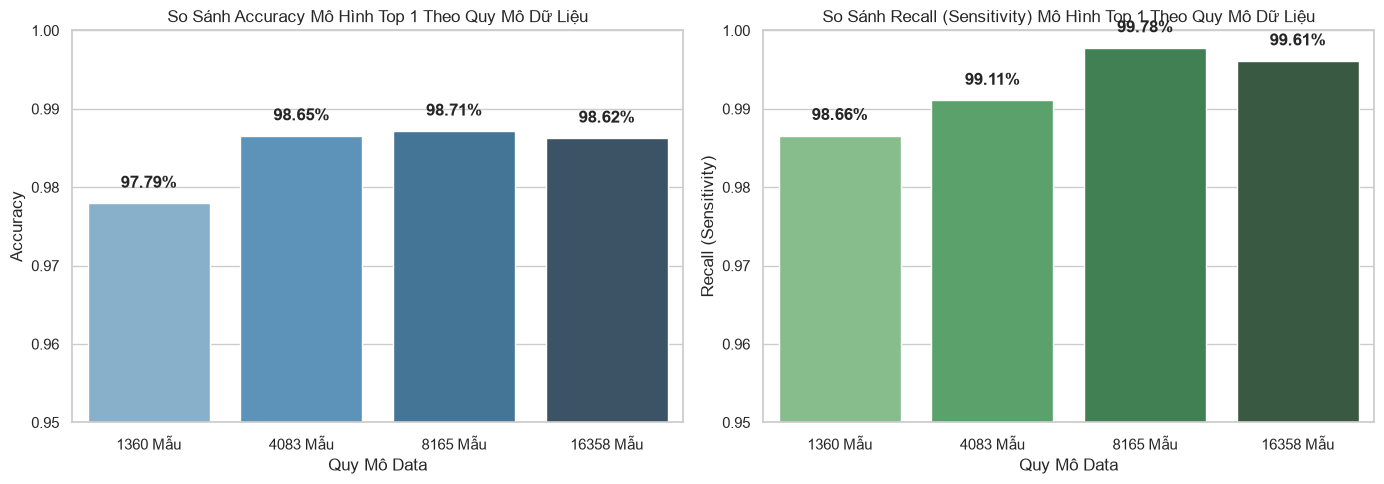

In [19]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=df_summary, x='Quy Mô Data', y='Accuracy', palette='Blues_d')
plt.title('So Sánh Accuracy Mô Hình Top 1 Theo Quy Mô Dữ Liệu')
plt.ylim(0.95, 1.0)
for i, v in enumerate(df_summary['Accuracy']):
    plt.text(i, v + 0.002, f'{v:.2%}', ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
sns.barplot(data=df_summary, x='Quy Mô Data', y='Recall (Sensitivity)', palette='Greens_d')
plt.title('So Sánh Recall (Sensitivity) Mô Hình Top 1 Theo Quy Mô Dữ Liệu')
plt.ylim(0.95, 1.0)
for i, v in enumerate(df_summary['Recall (Sensitivity)']):
    plt.text(i, v + 0.002, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()